In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
np.random.seed(42)

df['num_skills_listed'] = np.random.randint(1, 9, size=len(df))
df['has_portfolio'] = np.random.choice(['Yes', 'No'], size=len(df), p=[0.4, 0.6])
df['prior_hackathon_participation'] = np.random.choice(['Yes', 'No'], size=len(df), p=[0.3, 0.7])
df['statement_quality_score'] = np.random.randint(1, 11, size=len(df))

df.head()

,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score
0,Steven Miller,jessebenson@example.net,3171484348,Digital Marketing,FAST NUCES,NaN,Rejected,7,No,No,4
1,Megan Joyce,brownjessica@example.org,3127194416,App Development,FAST NUCES,2025-10-15,Under Review,4,No,No,6
2,Danielle Odonnell,davisrodney@example.com,3348030010,Digital Marketing,Karachi University,2025-01-08,Under Review,5,Yes,Yes,8
3,Thomas Bradley,jason76@example.net,3106438436,Web Development,LUMS,2025-12-30,Under Review,7,Yes,No,4
4,Kimberly Smith,housemelinda@example.org,3202813543,Web Development,Karachi University,2025-11-12,Selected,3,Yes,Yes,3


## Note on Simulated Features

The features num_skills_listed, has_portfolio, prior_hackathon_participation,
and statement_quality_score are simulated, not real historical data — this
dataset did not originally collect this information. In a real
NextGenLearners deployment, this data would need to be actually collected
from applications (e.g., a required skills field, a portfolio URL field)
before a model like this could be trusted for real decisions.

In [ ]:
df['has_portfolio'] = df['has_portfolio'].map({'Yes': 1, 'No': 0})
df['prior_hackathon_participation'] = df['prior_hackathon_participation'].map({'Yes': 1, 'No': 0})

In [ ]:
df['target'] = df['Status'].apply(lambda x: 1 if x == 'Selected' else 0)

In [ ]:
df_model = df[df['Status'] != 'Under Review'].copy()
print(df_model.shape)

(54, 12)


In [ ]:
df_model = pd.get_dummies(df_model, columns=['Domain Applied'], drop_first=True)
df_model.head()

,Applicant Name,Email,Phone,University,Application Date,Status,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score,target,Domain Applied_Data Science,Domain Applied_Digital Marketing,Domain Applied_Graphic Design,Domain Applied_Web Development
0,Steven Miller,jessebenson@example.net,3171484348,FAST NUCES,NaN,Rejected,7,0,0,4,0,False,True,False,False
4,Kimberly Smith,housemelinda@example.org,3202813543,Karachi University,2025-11-12,Selected,3,1,1,3,1,False,False,False,True
6,Heather Chavez,john13@example.com,3193180906,Sukkur IBA,2025-08-28,Selected,5,0,0,3,1,False,False,False,False
8,Steven Stevens,ryangross@example.net,3339906224,LUMS,2025-10-22,Selected,7,0,0,2,1,True,False,False,False
9,Mary Martinez,william65@example.com,3405638893,LUMS,2026-03-28,Selected,2,1,0,2,1,False,True,False,False


In [ ]:
feature_columns = ['num_skills_listed', 'has_portfolio',
                    'prior_hackathon_participation', 'statement_quality_score'] + \
                   [col for col in df_model.columns if col.startswith('Domain Applied_')]

X = df_model[feature_columns]
y = df_model['target']

print(feature_columns)

['num_skills_listed', 'has_portfolio', 'prior_hackathon_participation', 'statement_quality_score', 'Domain Applied_Data Science', 'Domain Applied_Digital Marketing', 'Domain Applied_Graphic Design', 'Domain Applied_Web Development']


## Feature Selection

We used num_skills_listed, has_portfolio, prior_hackathon_participation,
statement_quality_score, and the one-hot encoded Domain Applied columns as
features. We excluded Applicant Name, Email, Phone, University, and
Application Date — these are identifiers or metadata, not meaningful
predictive signals, and including them (especially Name/Email) would be
both useless and inappropriate for a selection model.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 43
Testing rows: 11


## Train/Test Split

The data was split 80/20 into training and test sets. Given our small
dataset of 52 rows, the test set contains only around 10-11 rows — this is
quite small, so results should be treated as illustrative of the method
rather than a statistically robust guarantee.

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained!")

Model trained!


## Model Training

We used Logistic Regression, a standard choice for Yes/No (binary)
predictions like this one. The model was trained on the 43 training rows
and then used to predict outcomes for the 11 unseen test rows.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 54.55%


In [ ]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Precision: 50.00%
Recall: 100.00%


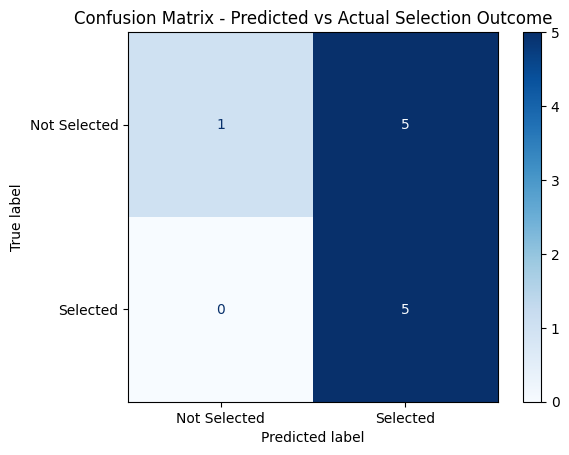

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Selected', 'Selected'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Predicted vs Actual Selection Outcome')
plt.show()

## Model Evaluation Results

- **Accuracy: 54.55%** — The model correctly predicted the outcome for about
  half of the test applicants. This is only slightly better than random
  guessing, which is expected given our very small dataset (43 training rows)
  and mostly simulated features.

- **Precision: 50.00%** — Of all the applicants the model predicted would be
  "Selected," only half were actually selected. This means the model makes
  a fair number of false promises.

- **Recall: 100.00%** — The model successfully caught every single applicant
  who was actually selected, missing none of them. However, combined with
  the low precision, this suggests the model is leaning toward predicting
  "Selected" more often than it should, rather than genuinely distinguishing
  between the two groups well.

**Interpretation:** With perfect recall but only 50% precision, the model
appears to be over-predicting "Selected" — it's better at not missing
selected candidates, but at the cost of also incorrectly flagging some
non-selected applicants. This pattern is common with very small, imbalanced
test sets (only 11 rows here) and reinforces that these results should be
treated as illustrative of the ML workflow, not as a reliable production model.

## Model Limitations

- **Small, partly simulated dataset:** Only 52 applicants had a final
  decision (Selected/Rejected), and 4 of the 8 features used were
  artificially simulated rather than real historical data.
- **Small test set instability:** With only 11 test rows, results can
  shift noticeably with a different train/test split — these numbers
  illustrate the ML workflow, not a production-ready guarantee.
- **Risk of bias:** If certain universities or domains were historically
  favored for reasons unrelated to merit, a model trained on that data
  would learn and repeat that same pattern. This is a genuine concern with
  any predictive hiring/selection tool.
- **Decision-support only:** This model should be treated as a tool to
  assist human reviewers, never as an automatic replacement for human
  judgment in selection decisions.

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

                            Feature  Coefficient
2     prior_hackathon_participation     0.259326
7    Domain Applied_Web Development    -0.016434
3           statement_quality_score    -0.016495
5  Domain Applied_Digital Marketing    -0.038151
6     Domain Applied_Graphic Design    -0.045688
4       Domain Applied_Data Science    -0.061101
0                 num_skills_listed    -0.204903
1                     has_portfolio    -0.429317


## Feature Importance Interpretation

**prior_hackathon_participation** had the strongest positive coefficient
(0.26) — in this dataset, the model associated prior hackathon experience
with a higher likelihood of being predicted "Selected." All other features
had small negative or near-zero coefficients, with **has_portfolio** (-0.43)
and **num_skills_listed** (-0.20) showing the most negative association.

**Important caveat:** Since 4 of these features were simulated rather than
real historical data, these results reflect only what the model learned
from this specific (partly artificial) dataset — they should not be
interpreted as real findings about NextGenLearners' actual selection
process. This would need to be validated against real historical data
before drawing any genuine conclusions. The very small dataset size (43
training rows) also means these coefficients could change noticeably with
more data.

## Executive Summary

**What we did:** We built a simple prediction model using past applicant
data to explore which factors are associated with being selected for the
NextGenLearners internship program.

**What we found:** The model correctly predicted selection outcomes for
about 55% of applicants in our test group — only slightly better than a
random guess. The factor most associated with a higher chance of selection
was whether the applicant had participated in a hackathon before.

**Important caveats:** This analysis used a small dataset (only 52
applicants with a final decision), and several factors — like number of
skills listed and statement quality — were artificially generated for this
exercise rather than pulled from real historical records. The model was
also overly cautious about predicting rejections, incorrectly flagging
several non-selected applicants as likely to be selected. Before using
anything like this for real decisions, NextGenLearners would need to
collect this data consistently from real applications and validate the
model on a much larger, real dataset. This model should be treated purely
as a decision-support tool to assist reviewers, never as an automatic
replacement for human judgment — especially given the risk that it could
unintentionally repeat biases from past decisions.

**Recommendation:** Consider adding a required "prior hackathon
participation" field to the application form and tracking it consistently,
since this was the strongest signal found in this exploratory analysis and
is worth validating with real data going forward.